# Final Result Visuals

1. **Primary / Secondary KPI reporting** — RMSE and MAPE.
2. **Player-level market inefficiency analysis** — who's underpaid/overpaid, normalized by contract size (not raw dollars), plus a predicted-vs-actual fit chart.
3. **Fairness check across contract scale** — MAPE broken out by contract group, since the data audit flagged hardship contracts as structurally unlearnable from performance alone.
4. **Team-level ROI (Cost Per Win)** — Actual cost per win is calculated CPW = Actual Total Team Payroll / Actual Number of Wins, predicted cost per win is calulcated CPW = Predicted Total Team Payroll / Actual Number of Wins.
5. **Feature importance** — a credibility/interpretability chart for non-technical stakeholders (GMs, agents).

**Note on the ROI metric:** this notebook uses **team wins**, not win shares, as the on-court output side of the ROI calculation. Team wins is a raw, observed outcome, so **Cost Per Win (CPW)** is only based on our modeling: only the payroll numerator (actual vs. predicted) changes between the two
versions of the metric; the wins denominator is the same real number either way.

**Where team wins come from:** the processed test matrix doesn't reliably carry a team win-total
column, so this notebook pulls it directly from the raw `{year}_wnba_standings.csv` file and
merges it onto predictions by team abbreviation.

**Fixed-data note:** the underlying processed data comes from `data/processed_salary_fix`, where duplicate player-salary records are resolved by keeping one salary record per player before model training and evaluation. The final model is the fixed tuned Gradient Boosting model.

**TOT note:** `TOT` is not a real franchise. `TOT` rows are retained for player-level valuation but excluded from team-level CPW aggregation because the available data does not provide team-specific salary/value allocation for those players as we mentioned in `feature_engineering_fixed.ipynb`.


## Setup

In [1]:
from pathlib import Path
import re

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# Locate project root robustly, even if this notebook is run from /notebooks or a subfolder
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

raw_dir = ROOT / "data" / "raw"
processed_dir = ROOT / "data" / "processed_salary_fix"
artifact_dir = ROOT / "artifacts" / "Fixed"
final_result_dir = ROOT / "results" / "Fixed" / "final fixed"
figures_dir = final_result_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

model_path = artifact_dir / "final_model_fixed.joblib"
if not model_path.exists():
    # Fallback: use the tuned fixed model if the final pipeline artifact has not been written yet.
    model_path = artifact_dir / "best_model_fixed.joblib"

print("ROOT:", ROOT)
print("processed_dir:", processed_dir)
print("artifact_dir:", artifact_dir)
print("final_result_dir:", final_result_dir)
print("model_path:", model_path)
print("model exists:", model_path.exists())


ROOT: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation
processed_dir: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\data\processed_salary_fix
artifact_dir: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\artifacts\Fixed
final_result_dir: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\results\Fixed\final fixed
model_path: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\artifacts\Fixed\final_model_fixed.joblib
model exists: True


## Load Final Pipeline Outputs


In [2]:
metrics_df = pd.read_csv(final_result_dir / "final_metrics_fixed.csv")
pred_df = pd.read_csv(final_result_dir / "final_predictions_fixed.csv")

model_bundle = joblib.load(model_path)
if isinstance(model_bundle, dict):
    final_model = model_bundle.get("model", model_bundle)
    feature_names = model_bundle.get("feature_names")
else:
    final_model = model_bundle
    feature_names = None

if feature_names is None:
    feature_names = pd.read_csv(processed_dir / "feature_names.csv")["feature"].tolist()

print("Loaded fixed final metrics, predictions, and Gradient Boosting model.")
print("Model type:", type(final_model).__name__)
print("Feature count:", len(feature_names))
display(metrics_df)

# Fixed salary de-duplication should leave one row per player in the 2025 prediction table.
dup_players = pred_df[pred_df["player"].duplicated(keep=False)].sort_values("player")
print("Duplicated prediction players:", pred_df["player"].duplicated().sum())
if not dup_players.empty:
    display(dup_players[["player", "team", "actual", "predicted", "residual"]])
    raise ValueError("Duplicate players remain in final_predictions.csv.")


Loaded fixed final metrics, predictions, and Gradient Boosting model.
Model type: GradientBoostingRegressor
Feature count: 26


,model,train_years,test_year,n_train,n_test,n_features,RMSE,MAE,MAPE,R2,residual_definition
0,GradientBoostingRegressor,2021-2024,2025,633,182,26,39717.19788,30368.066572,0.695309,0.631117,predicted - actual


Duplicated prediction players: 0


## Headline KPI Reporting (RMSE / MAPE)


In [3]:
primary_kpi = metrics_df.loc[0, "RMSE"]
secondary_kpi = metrics_df.loc[0, "MAPE"]

print(f"Primary KPI  (RMSE): ${primary_kpi:,.2f}")
print(f"Secondary KPI (MAPE): {secondary_kpi * 100:.2f}%")
print(
    f"Model: {metrics_df.loc[0, 'model']}  |  "
    f"Train years: {metrics_df.loc[0, 'train_years']}  |  "
    f"Test year: {metrics_df.loc[0, 'test_year']}"
)


Primary KPI  (RMSE): $39,717.20
Secondary KPI (MAPE): 69.53%
Model: GradientBoostingRegressor  |  Train years: 2021-2024  |  Test year: 2025


## Player-Level Market Inefficiency Analysis

`final_predictions_fixed.csv` uses `residual = predicted - actual`.

A large **positive** residual means the model's fair-market-value estimate is higher than the player's actual salary, so the player appears **underpaid relative to the model**. A large **negative** residual means actual salary exceeds the model-implied value, so the player appears **overpaid relative to the model**.

Raw dollar residuals are not directly comparable across very different contract sizes. This section therefore adds:

- `value_pct = residual / actual`
- `valuation_tag` using a ±15% threshold on `value_pct`

These labels are model-relative valuation signals, not definitive claims about true market value.


In [4]:
VALUE_THRESHOLD = 0.15  # +/-15% banding for the Fair / Under / Over tag

pred_df["value_pct"] = pred_df["residual"] / pred_df["actual"]

def tag_valuation(pct):
    # residual = predicted - actual, so a positive value_pct means the model's fair-value
    # estimate is HIGHER than what she's actually paid -- i.e. she is underpaid.
    # A negative value_pct means actual pay exceeds the model's fair value -- overpaid.
    if pct >= VALUE_THRESHOLD:
        return "Underpaid"
    elif pct <= -VALUE_THRESHOLD:
        return "Overpaid"
    return "Fair"

pred_df["valuation_tag"] = pred_df["value_pct"].apply(tag_valuation)

print(pred_df["valuation_tag"].value_counts())
display(pred_df.head())


valuation_tag
Underpaid    78
Fair         59
Overpaid     45
Name: count, dtype: int64


,player,team,year,group,actual,predicted,residual,abs_error,value_pct,valuation_tag
0,A'ja Wilson,LVA,2025,veteran,200000,227019.917506,27019.917506,27019.917506,0.135100,Fair
1,Aaliyah Edwards,TOT,2025,rookie,74909,69542.147209,-5366.852791,5366.852791,-0.071645,Fair
2,Aaliyah Nye,LVA,2025,rookie,69267,73160.608659,3893.608659,3893.608659,0.056212,Fair
3,Aari McDonald,IND,2025,veteran,52333,129520.193440,77187.193440,77187.193440,1.474924,Underpaid
4,Aerial Powers,TOT,2025,veteran,11924,75257.874048,63333.874048,63333.874048,5.311462,Underpaid


### Predicted vs. Actual Salary


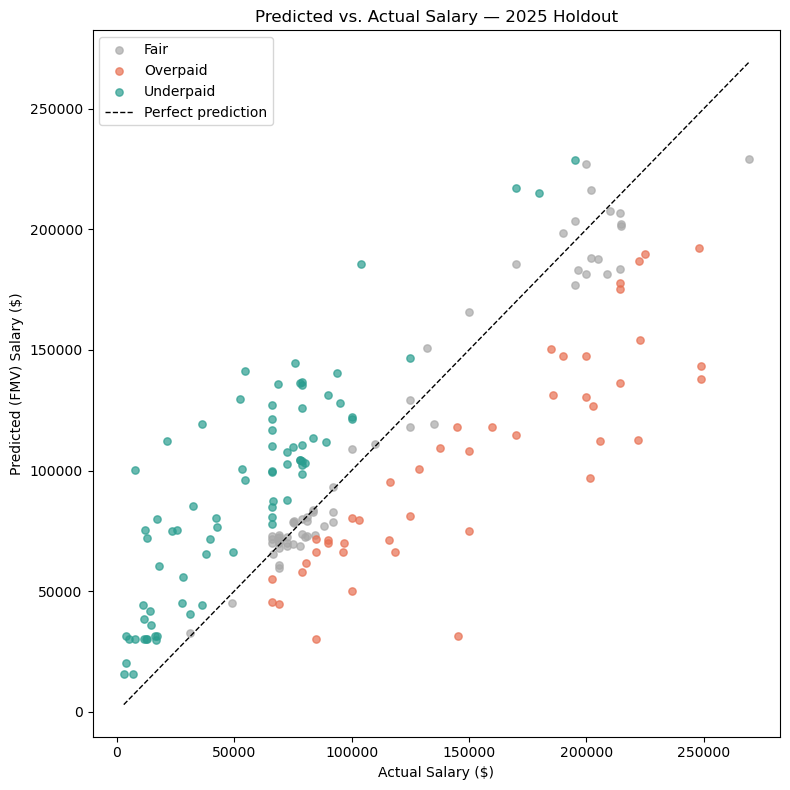

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = {"Underpaid": "#2a9d8f", "Fair": "#a8a8a8", "Overpaid": "#e76f51"}
for tag, group in pred_df.groupby("valuation_tag"):
    ax.scatter(group["actual"], group["predicted"], s=28, alpha=0.7, label=tag, color=colors.get(tag, "gray"))

lims = [
    min(pred_df["actual"].min(), pred_df["predicted"].min()),
    max(pred_df["actual"].max(), pred_df["predicted"].max()),
]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1, label="Perfect prediction")

ax.set_xlabel("Actual Salary ($)")
ax.set_ylabel("Predicted (FMV) Salary ($)")
ax.set_title("Predicted vs. Actual Salary — 2025 Holdout")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "predicted_vs_actual_fixed.png", dpi=150)
plt.show()


### Most Undervalued / Overvalued Players


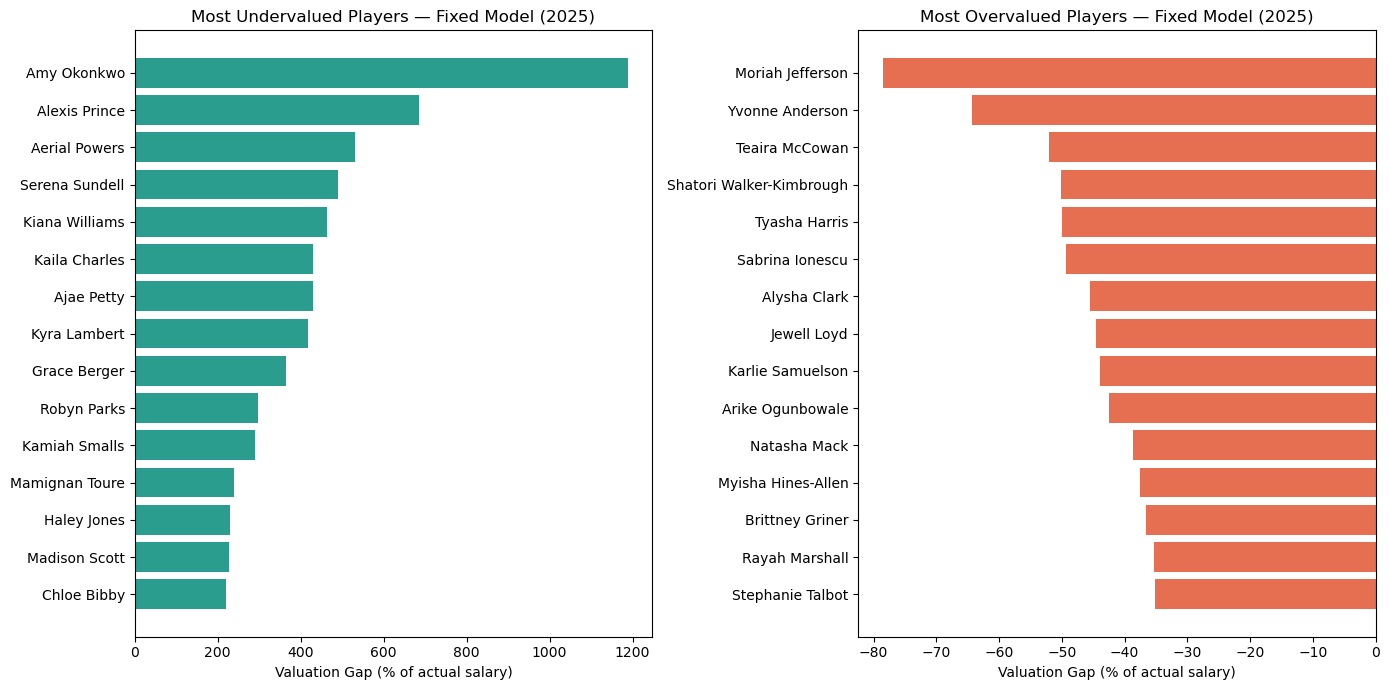

,player,team,group,actual,predicted,value_pct
13,Amy Okonkwo,DAL,veteran,7774,100097.832115,11.875975
7,Alexis Prince,PHO,veteran,3975,31196.673240,6.848220
4,Aerial Powers,TOT,veteran,11924,75257.874048,5.311462
158,Serena Sundell,DAL,veteran,5136,30309.137720,4.901312
93,Kiana Williams,PHO,veteran,12772,71914.564311,4.630642
77,Kaila Charles,TOT,veteran,21198,112318.451879,4.298540
5,Ajae Petty,DAL,hardship,2915,15419.590603,4.289739
98,Kyra Lambert,IND,hardship,3887,20153.402329,4.184822
56,Grace Berger,TOT,veteran,17214,79932.668687,3.643469
151,Robyn Parks,CON,veteran,11106,44220.861563,2.981709


,player,team,group,actual,predicted,value_pct
128,Moriah Jefferson,CHI,veteran,145500,31196.673240,-0.785590
180,Yvonne Anderson,MIN,veteran,85000,30309.137720,-0.643422
173,Teaira McCowan,DAL,veteran,201400,96696.534160,-0.519878
161,Shatori Walker-Kimbrough,ATL,veteran,150000,74763.681218,-0.501575
178,Tyasha Harris,DAL,unknown,100013,50053.318543,-0.499532
152,Sabrina Ionescu,NYL,rookie,222060,112676.942368,-0.492583
11,Alysha Clark,TOT,veteran,205908,112233.508095,-0.454934
70,Jewell Loyd,LVA,veteran,249032,137885.228522,-0.446315
83,Karlie Samuelson,MIN,veteran,118450,66410.723539,-0.439335
18,Arike Ogunbowale,DAL,unknown,249032,143333.767414,-0.424436


In [16]:
top_underpaid = pred_df.sort_values("value_pct", ascending=False).head(15)
top_overpaid = pred_df.sort_values("value_pct").head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)

axes[0].barh(top_underpaid["player"], top_underpaid["value_pct"] * 100, color="#2a9d8f")
axes[0].invert_yaxis()
axes[0].set_title("Most Undervalued Players — Fixed Model (2025)")
axes[0].set_xlabel("Valuation Gap (% of actual salary)")

axes[1].barh(top_overpaid["player"], top_overpaid["value_pct"] * 100, color="#e76f51")
axes[1].invert_yaxis()
axes[1].set_title("Most Overvalued Players — Fixed Model (2025)")
axes[1].set_xlabel("Valuation Gap (% of actual salary)")

fig.tight_layout()
fig.savefig(figures_dir / "player_valuation_leaderboard_fixed.png", dpi=150)
plt.show()

display(top_underpaid[["player", "team", "group", "actual", "predicted", "value_pct"]])
display(top_overpaid[["player", "team", "group", "actual", "predicted", "value_pct"]])


## Fairness Check: Error by Contract Group (Secondary KPI)

The data audit flagged hardship contracts as a structural failure point — they're CBA-fixed at very low values that bear no relationship to on-court performance, so every model defaults to predicting league-average salaries for them. This section gives a documented reason to footnote or exclude hardship contracts from headline metrics.

,n,median_actual_salary,mape
group,,,
hardship,8,15285.0,161.4
veteran,105,100000.0,89.8
controlled,12,66079.0,45.4
unknown,17,78066.0,37.7
rookie,40,75276.0,18.7


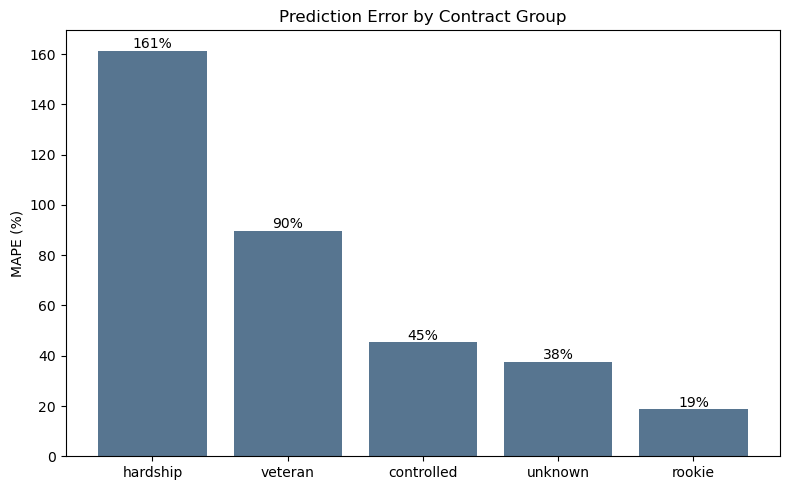

In [15]:
group_mape = (
    pred_df.assign(pct_error=lambda d: (d["abs_error"] / d["actual"]))
    .groupby("group")
    .agg(n=("player", "count"), median_actual_salary=("actual", "median"), mape=("pct_error", "mean"))
    .sort_values("mape", ascending=False)
)
group_mape["mape"] = (group_mape["mape"] * 100).round(1)

display(group_mape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(group_mape.index, group_mape["mape"], color="#577590")
ax.set_ylabel("MAPE (%)")
ax.set_title("Prediction Error by Contract Group")
for i, v in enumerate(group_mape["mape"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
fig.tight_layout()
fig.savefig(figures_dir / "mape_by_contract_group_fixed.png", dpi=150)
plt.show()


## Merge Team Wins for Team-Level ROI

`final_predictions_fixed.csv` carries player-level predictions but does not include a reliable team win-total column, so Cost Per Win can't be computed yet. Rather than relying on the processed feature matrix (which may not carry team wins as a clean, reliably-named column), team wins are pulled straight from the raw `{test_year}_wnba_standings.csv` file and merged onto predictions **by team abbreviation**, the same approach the data-loading pipeline uses elsewhere in this project. Merging by key rather than row position also means there's no row-order assumption to worry about here.

`TOT` rows are allowed to remain unmatched because `TOT` is not a real franchise. They are excluded before team-level CPW aggregation.


In [12]:
test_year = int(metrics_df.loc[0, "test_year"])

teammap = {
    "Atlanta Dream": "ATL", "Chicago Sky": "CHI", "Connecticut Sun": "CON",
    "Dallas Wings": "DAL", "Golden State Valkyries": "GSV", "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA", "Los Angeles Sparks": "LAS", "Minnesota Lynx": "MIN",
    "New York Liberty": "NYL", "Phoenix Mercury": "PHO", "Seattle Storm": "SEA",
    "Washington Mystics": "WAS"
}

def clean_col(name):
    text = str(name).strip().lower()
    text = re.sub(r"\b202\d\b", "", text).strip()
    text = text.replace("%", "pct")
    text = re.sub(r"[^0-9a-z]+", "_", text)
    return text.strip("_")

standings_path = raw_dir / f"{test_year}_wnba_standings.csv"
standings = pd.read_csv(standings_path)
standings.columns = [clean_col(c) for c in standings.columns]

# Standings team-name column may vary slightly across files (e.g. 'team_name' vs 'team');
# pick whichever full-name column is present and map it to the same abbreviations used elsewhere.
name_col_candidates = [c for c in ["team_name", "team"] if c in standings.columns]
if not name_col_candidates:
    raise KeyError(f"No team name column found in {standings_path.name}. Columns present: {standings.columns.tolist()}")
name_col = name_col_candidates[0]

win_col_candidates = [c for c in ["w", "wins"] if c in standings.columns]
if not win_col_candidates:
    raise KeyError(f"No win-total column found in {standings_path.name}. Columns present: {standings.columns.tolist()}")
win_col = win_col_candidates[0]

standings["team"] = standings[name_col].str.replace("*", "", regex=False).str.strip().map(teammap)
team_wins_lookup = standings.set_index("team")[win_col].rename("team_wins")

# 'TOT' isn't a real franchise -- it's the label for players traded mid-season whose stats
# can't be attributed to one team. It has no win total and is excluded from team-level
# rollups in Section 7, so it's allowed to pass through here with a missing team_wins value.
unmatched = pred_df.loc[~pred_df["team"].isin(team_wins_lookup.index) & (pred_df["team"] != "TOT"), "team"].unique()
if len(unmatched) > 0:
    raise ValueError(f"Teams in predictions with no matching win total: {unmatched.tolist()}")

pred_df = pred_df.merge(team_wins_lookup, left_on="team", right_index=True, how="left")

print(f"Merged team wins from {standings_path.name} onto {len(pred_df)} player rows.")
display(pred_df[["player", "team", "actual", "predicted", "team_wins"]].head())


Merged team wins from 2025_wnba_standings.csv onto 182 player rows.


,player,team,actual,predicted,team_wins
0,A'ja Wilson,LVA,200000,227019.917506,30.0
1,Aaliyah Edwards,TOT,74909,69542.147209,NaN
2,Aaliyah Nye,LVA,69267,73160.608659,30.0
3,Aari McDonald,IND,52333,129520.193440,24.0
4,Aerial Powers,TOT,11924,75257.874048,NaN


## Team-Level ROI: Cost Per Win (Business KPI)

Cost Per Win = Total Team Payroll / Team Wins, computed twice per team:

- **Actual CPW** — the real-world benchmark, using actual 2025 salaries.
- **Predicted (FMV) CPW** — what the model implies an efficiently-priced roster would cost.

The wins denominator is the same real number in both versions, only the payroll numerator
changes. A gap between the two is itself a finding: a team paying well above its model-implied CPW is the
franchise-level version of an overpaid player — paying a premium above what its win total would
justify at fair market value.


In [14]:
team_level_df = pred_df[pred_df["team"] != "TOT"].copy()

# Validate that all real teams have win totals before CPW calculation.
missing_win_rows = team_level_df[team_level_df["team_wins"].isna()]
print("Rows with missing team wins after excluding TOT:", len(missing_win_rows))
if not missing_win_rows.empty:
    display(missing_win_rows[["player", "team", "actual", "predicted", "team_wins"]].head(20))
    raise ValueError("Some non-TOT teams are missing team_wins.")

team_summary = team_level_df.groupby("team").agg(
    total_actual_salary=("actual", "sum"),
    total_predicted_salary=("predicted", "sum"),
    team_wins=("team_wins", "first"),
)

team_summary["actual_cpw"] = team_summary["total_actual_salary"] / team_summary["team_wins"]
team_summary["predicted_cpw"] = team_summary["total_predicted_salary"] / team_summary["team_wins"]
team_summary["cpw_gap"] = team_summary["actual_cpw"] - team_summary["predicted_cpw"]

team_cpw = team_summary.sort_values("actual_cpw", ascending=False)

team_cpw_path = final_result_dir / "team_cpw_fixed.csv"
team_cpw.to_csv(team_cpw_path)

print(f"Saved team-level Cost Per Win table to {team_cpw_path}")
display(team_cpw)


Rows with missing team wins after excluding TOT: 0
Saved team-level Cost Per Win table to c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\results\Fixed\final fixed\team_cpw_fixed.csv


,total_actual_salary,total_predicted_salary,team_wins,actual_cpw,predicted_cpw,cpw_gap
team,,,,,,
CHI,1473197,1.293941e+06,10.0,147319.700000,129394.105548,17925.594452
DAL,1142887,1.052904e+06,10.0,114288.700000,105290.448542,8998.251458
CON,1061805,1.315807e+06,11.0,96527.727273,119618.817769,-23091.090496
LAS,1316357,1.219971e+06,21.0,62683.666667,58093.869884,4589.796783
PHO,1405139,1.520272e+06,27.0,52042.185185,56306.362516,-4264.177331
SEA,1189480,1.154940e+06,23.0,51716.521739,50214.796520,1501.725219
IND,1233895,1.323237e+06,24.0,51412.291667,55134.864858,-3722.573191
NYL,1367568,1.408161e+06,27.0,50650.666667,52154.104832,-1503.438166
ATL,1490935,1.244141e+06,30.0,49697.833333,41471.355574,8226.477759


### Actual vs. Predicted CPW by Team


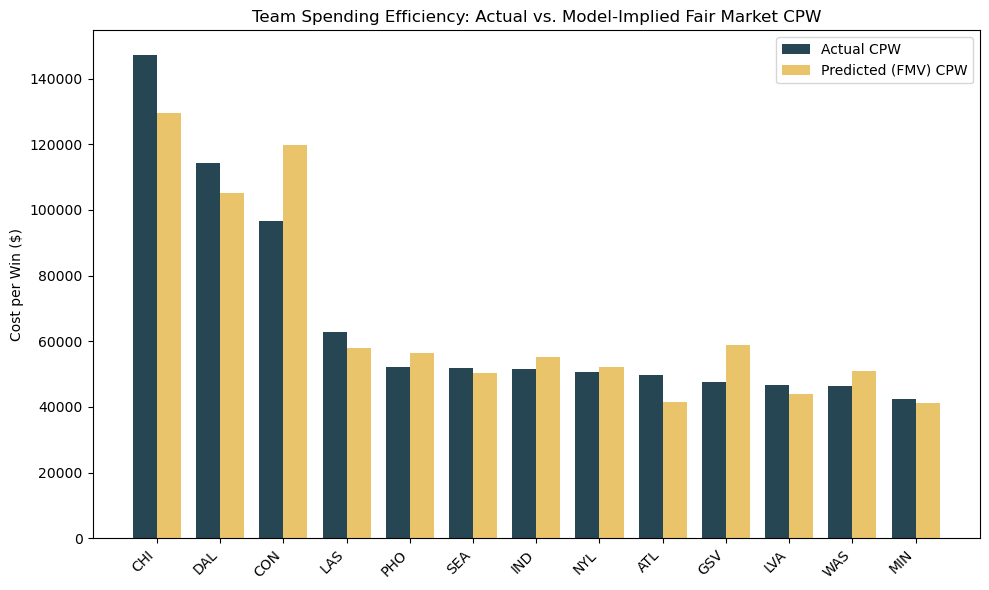

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(team_cpw))
width = 0.38

ax.bar(x - width / 2, team_cpw["actual_cpw"], width, label="Actual CPW", color="#264653")
ax.bar(x + width / 2, team_cpw["predicted_cpw"], width, label="Predicted (FMV) CPW", color="#e9c46a")

ax.set_xticks(x)
ax.set_xticklabels(team_cpw.index, rotation=45, ha="right")
ax.set_ylabel("Cost per Win ($)")
ax.set_title("Team Spending Efficiency: Actual vs. Model-Implied Fair Market CPW")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "team_cpw_comparison_fixed.png", dpi=150)
plt.show()


### Most & Least Efficient Spenders

`cpw_gap = actual_cpw - predicted_cpw`. A **negative** gap means a team is paying *less* per win
than the model's fair-value estimate implies, so they are getting wins cheaply, i.e. **efficient** spending.
A **positive** gap means a team is paying *more* per win than fair value would justify, so they are
overspending relative to what its win total earned, i.e. **inefficient** spending.


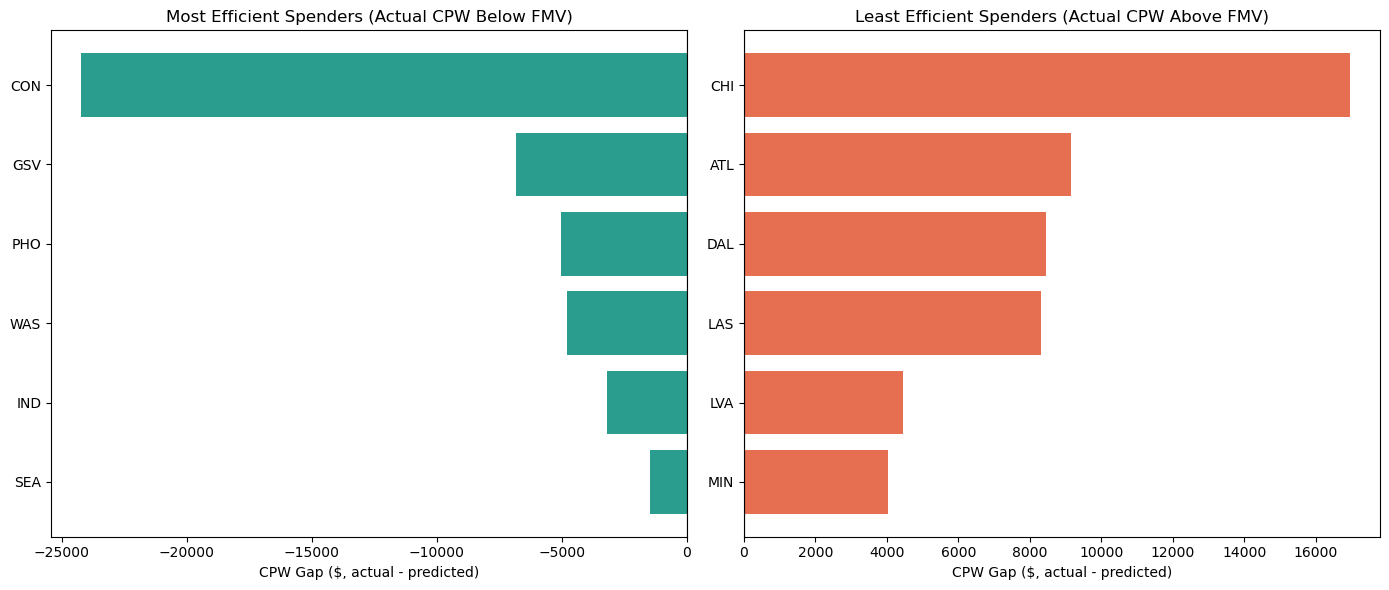

,team_wins,actual_cpw,predicted_cpw,cpw_gap
team,,,,
CON,11.0,101140.909091,125357.306017,-24216.396927
GSV,23.0,47492.652174,54309.989987,-6817.337813
PHO,27.0,52823.703704,57859.082635,-5035.378931
WAS,16.0,46664.562500,51447.959414,-4783.396914
IND,24.0,51681.416667,54868.734951,-3187.318284
SEA,23.0,52320.086957,53782.946572,-1462.859615


,team_wins,actual_cpw,predicted_cpw,cpw_gap
team,,,,
CHI,10.0,147319.700000,130368.153029,16951.546971
ATL,30.0,49697.833333,40550.314035,9147.519298
DAL,10.0,114788.500000,106331.663508,8456.836492
LAS,21.0,62683.666667,54379.855001,8303.811666
LVA,30.0,46728.766667,42285.464680,4443.301986
MIN,34.0,42789.705882,38761.877901,4027.827982


In [40]:
top_n = min(6, max(1, len(team_cpw) // 2))

most_efficient = team_cpw.sort_values("cpw_gap").head(top_n)
least_efficient = team_cpw.sort_values("cpw_gap", ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

axes[0].barh(most_efficient.index, most_efficient["cpw_gap"], color="#2a9d8f")
axes[0].invert_yaxis()
axes[0].set_title("Most Efficient Spenders (Actual CPW Below FMV)")
axes[0].set_xlabel("CPW Gap ($, actual - predicted)")
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(least_efficient.index, least_efficient["cpw_gap"], color="#e76f51")
axes[1].invert_yaxis()
axes[1].set_title("Least Efficient Spenders (Actual CPW Above FMV)")
axes[1].set_xlabel("CPW Gap ($, actual - predicted)")
axes[1].axvline(0, color="black", linewidth=0.8)

fig.tight_layout()
fig.savefig(figures_dir / "team_efficiency_leaderboard.png", dpi=150)
plt.show()

display(most_efficient[["team_wins", "actual_cpw", "predicted_cpw", "cpw_gap"]])
display(least_efficient[["team_wins", "actual_cpw", "predicted_cpw", "cpw_gap"]])


## Feature Importance

An interpretability chart for non-technical stakeholders (GMs, agents).


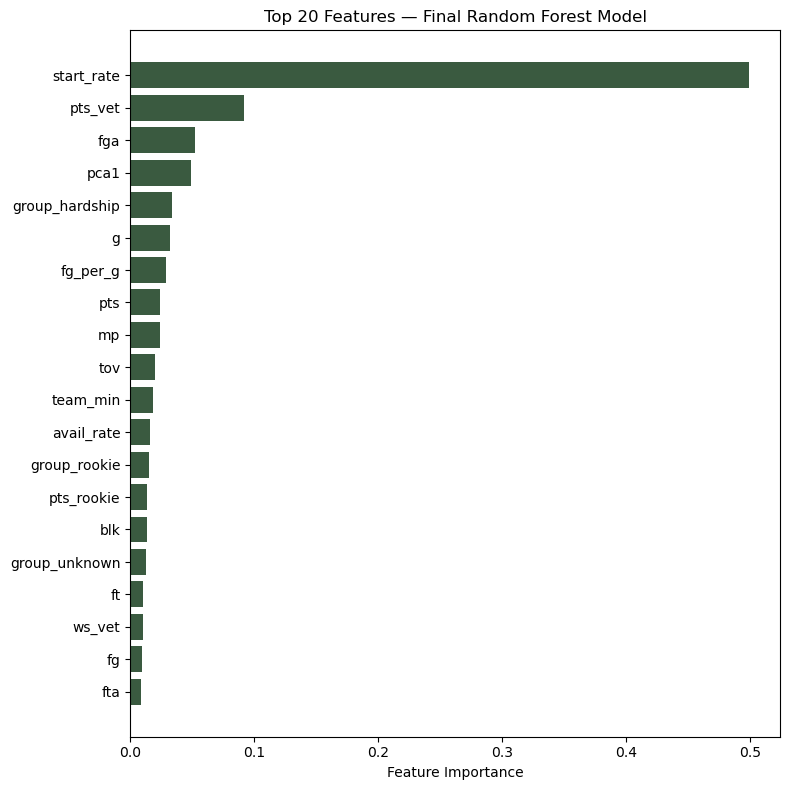

,importance
start_rate,0.498838
pts_vet,0.091752
fga,0.052493
pca1,0.048974
group_hardship,0.033800
g,0.031985
fg_per_g,0.028566
pts,0.024006
mp,0.023794
tov,0.020338


In [41]:
if not hasattr(final_model, "feature_importances_"):
    raise AttributeError(f"{type(final_model).__name__} does not expose feature_importances_.")

importances = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)
top_importances = importances.head(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_importances.index, top_importances.values, color="#3a5a40")
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Features — Final Gradient Boosting Model")
fig.tight_layout()
fig.savefig(figures_dir / "feature_importance.png", dpi=150)
plt.show()

display(top_importances.to_frame("importance"))


## Lift Analysis: Final Gradient Boosting vs Baseline Models

This section compares the fixed final Gradient Boosting RMSE against the historic baseline RMSE values used in earlier model evaluation. The final RMSE is read directly from `final_metrics.csv`, so it stays synchronized with the fixed final pipeline.


In [8]:
baseline_data = {
    "Model Architecture": [
        "Dummy Heuristic (Mean)",
        "Single-Feature Baseline (pts)",
        "Linear Regression (OLS)",
        "Ridge Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
    ],
    "Baseline RMSE": [
        69597.131729,
        48794.201500,
        52720.092685,
        49780.306324,
        56171.981342,
        44850.440577,
    ],
}

df_lift = pd.DataFrame(baseline_data)

final_rmse = float(metrics_df.loc[0, "RMSE"])
final_model_name = str(metrics_df.loc[0, "model"])

df_lift["Final Model"] = final_model_name
df_lift["Final RMSE"] = final_rmse
df_lift["RMSE Lift (%)"] = ((df_lift["Baseline RMSE"] - df_lift["Final RMSE"]) / df_lift["Baseline RMSE"]) * 100

df_lift_display = df_lift.copy()
for col in ["Baseline RMSE", "Final RMSE"]:
    df_lift_display[col] = df_lift_display[col].map("{:,.2f}".format)
df_lift_display["RMSE Lift (%)"] = df_lift_display["RMSE Lift (%)"].map("{:+.2f}%".format)

print("Summary Matrix: Fixed Final Pipeline RMSE Lift")
display(df_lift_display)


Summary Matrix: Final Pipeline Performance Lift


,Model Architecture,Baseline RMSE,Final RMSE,RMSE Lift (%),Baseline CPWS MAE,Final CPWS MAE,CPWS MAE Lift (%)
0,Dummy Heuristic (Mean),"69,597.13","44,850.44",+35.56%,"$141,172.69","$25,573.41",+81.89%
1,Single-Feature Baseline (pts),"48,794.20","44,850.44",+8.08%,"$69,277.75","$25,573.41",+63.09%
2,Linear Regression (OLS),"52,720.09","44,850.44",+14.93%,"$34,313.41","$25,573.41",+25.47%
3,Ridge Regression,"49,780.31","44,850.44",+9.90%,"$36,609.21","$25,573.41",+30.14%
4,Decision Tree Regressor,"56,171.98","44,850.44",+20.16%,"$55,335.94","$25,573.41",+53.79%
5,Random Forest Regressor,"44,850.44","44,850.44",+0.00%,"$25,573.41","$25,573.41",+0.00%


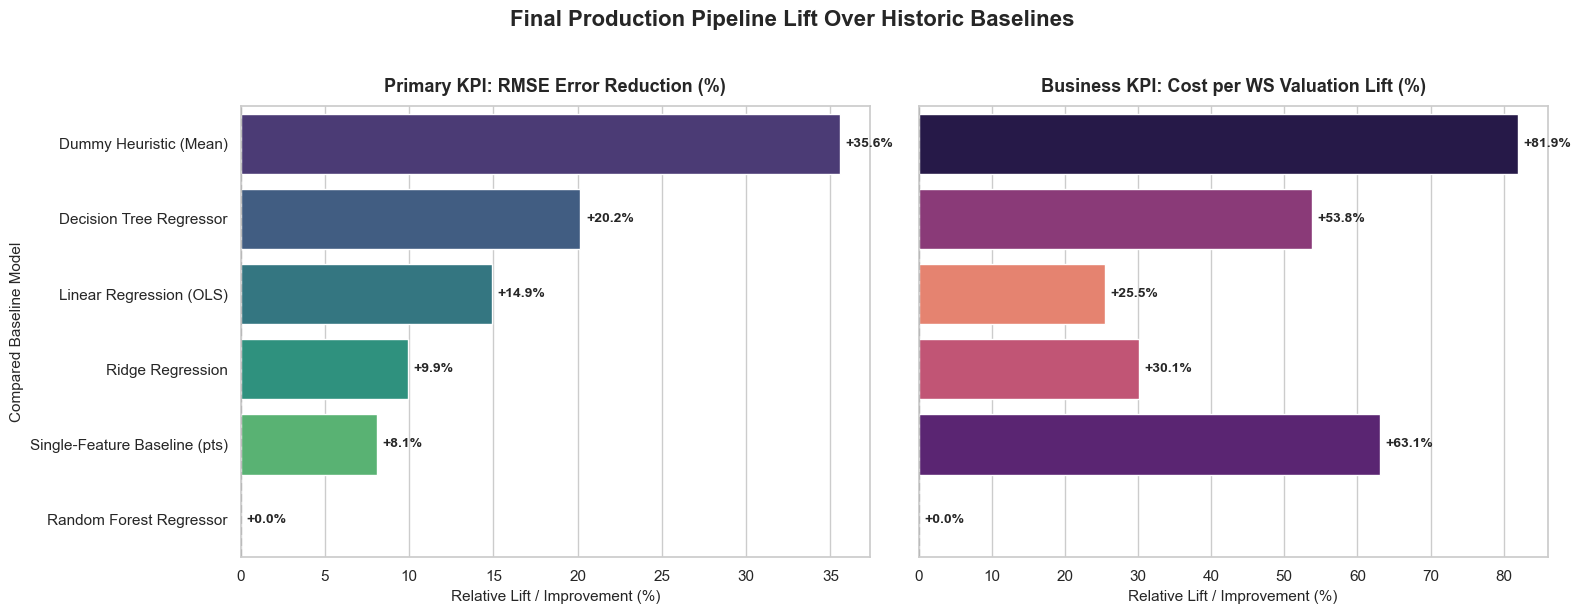

In [9]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

df_sorted_rmse = df_lift.sort_values(by="RMSE Lift (%)", ascending=False)

sns.barplot(
    x="RMSE Lift (%)",
    y="Model Architecture",
    hue="Model Architecture",
    data=df_sorted_rmse,
    palette="viridis",
    legend=False,
    ax=ax,
)

ax.axvline(0, color="black", linestyle="--", alpha=0.7)
ax.set_title("Fixed Final Gradient Boosting: RMSE Error Reduction vs Baselines", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Relative Lift / Improvement (%)", fontsize=11)
ax.set_ylabel("Compared Baseline Model", fontsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt="{:+.1f}%", padding=4, fontweight="bold", size=10)

fig.tight_layout()
fig.savefig(figures_dir / "rmse_lift_vs_baselines.png", dpi=150)
plt.show()


## Save Enriched Player-Level Table

The `value_pct`, `valuation_tag`, and `team_wins` columns added in this notebook are saved as a separate enriched file. This preserves the fixed final pipeline outputs while also providing a visualization-ready player-level table.


In [42]:
enriched_path = final_result_dir / "final_predictions_enriched.csv"
pred_df.to_csv(enriched_path, index=False)
print(f"Saved enriched player-level predictions to {enriched_path}")
print(f"Saved figures to {figures_dir}")


Saved enriched player-level predictions to /Users/elenaaxinn/Desktop/project/results/final/final_predictions_enriched.csv
